In [160]:
import numpy as np
import matplotlib.pyplot as plt

def random_trader():
    random_list = np.random.randint(low=0, high=100, size=3)
    while random_list.sum() > 100 or random_list.sum() < 50:
        random_list = np.random.randint(low=0, high=100, size=3)
    return random_list
    
def get_trader_ranks(traders: list[np.ndarray]):
    scale_dict = {}
    for trader in traders:
        scale = int(trader[2])
        if scale not in scale_dict:
            scale_dict[scale] = 0
        scale_dict[scale] += 1
    
    scale_list = []
    for key, val in scale_dict.items():
        scale_list.append([key, val])
    scale_list.sort(key = lambda x: -x[0])

    cur_rank = 1
    max_rank = 1
    ranks = {}
    for l in scale_list:
        ranks[l[0]] = cur_rank
        max_rank = cur_rank
        cur_rank += l[1]
    return ranks, max_rank

def calculate_trader_scores(traders: list[np.ndarray]):
    ranks, max_rank = get_trader_ranks(traders)
    slope = -0.8 / (max_rank - 1)

    # 1 --> 0.9; mr --> 0.1
    # slope = (0.1 - 0.9) / (mr - 1)
    # y - 0.9 = slope (x - 1)
    # y = (0.9 - slope) + slope * x

    result = []
    for trader in traders:
        research = 200000 * np.log(1 + trader[0]) / np.log(1 + 100)
        scale = 7 * trader[1] / 100
        speed = (0.9 - slope) + slope * ranks[trader[2]]
        # print(research, "\t", scale, "\t", speed)
        if not (0.1 <= speed <= 0.9):
            speed = max(min(speed, 0.9), 0.1) # PYTHON IS KHOOOOOOSE
        assert(research >= 0)
        assert(0.1 <= speed <= 0.9)
        result.append(research * scale * speed - 50000 * trader.sum() / 100)
    return result

In [161]:
# time to test

# some number of traders idk
traders = [random_trader() for _ in range(19)]
traders.append(np.array([23, 50, 27]))
result = calculate_trader_scores(traders)
for i in range(len(traders)):
    print(traders[i], "\t", int(traders[i].sum()), "\t", round(result[i]))

[11 17 41] 	 69 	 80831
[41 33 20] 	 94 	 147958
[26 42 19] 	 87 	 139936
[ 2 55 16] 	 73 	 20418
[12 41 37] 	 90 	 228679
[57 33  6] 	 96 	 26877
[25 23 37] 	 85 	 152516
[35 16 30] 	 81 	 72097
[ 3 52  9] 	 64 	 17490
[13 31 35] 	 79 	 152508
[45 15  4] 	 64 	 -14579
[ 8 59 33] 	 100 	 237695
[ 7 38  6] 	 51 	 18656
[19 32 20] 	 71 	 116023
[15 26 15] 	 56 	 30698
[ 7 52 19] 	 78 	 104291
[18 21 32] 	 71 	 93826
[17 12 28] 	 57 	 35183
[ 3 38 17] 	 58 	 27351
[23 50 27] 	 100 	 221460


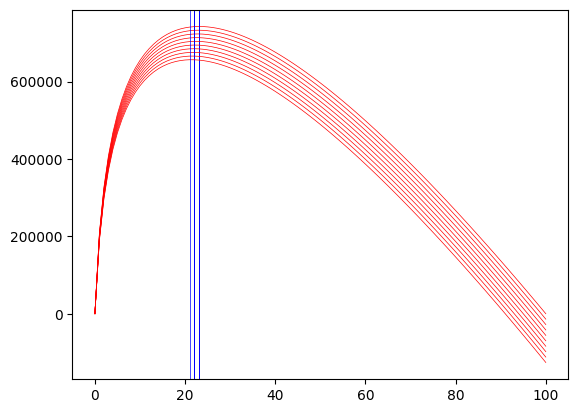

In [162]:
# plot research - get a better grasp of what's needed

rrr = np.arange(0, 101, 1)
speed_pct_to_research_pct = {}

def research_times_scale(r):
    return 200000 * np.log(1 + r) / np.log(1 + 100) * 7 / 100 * ((100 - k) - r)

# take k to be the proportion spent on fighting those NERDS (speed stat)
for k in range(10):
    plt.plot(rrr, research_times_scale(rrr), color = 'r', lw = 0.5)
    best_r = -1
    best_r_profit = 0
    for r in range(100 - k):
        profit = research_times_scale(r)
        if profit >= best_r_profit:
            best_r = r
            best_r_profit = profit
    speed_pct_to_research_pct[k] = int(best_r)
    plt.axvline(best_r, color = 'b', lw = 0.5)

# print(speed_pct_to_research_pct)
plt.show()

In [163]:
# next step is to figure out a prior for the distribution of the speed stat

# prior:
# 50% - 60%: plays balanced
#  5% - 10%: concentrates on research
#  5% - 10%: concentrates on scale
# 10% - 15%: concentrates on speed
#  5% - 10%: picks randomly

def balanced_trader():
    pass

def research_trader():
    pass

def scale_trader():
    pass

def speed_trader():
    pass

In [164]:
import random as rd
from copy import deepcopy

def run_trial():
    balanced = rd.uniform(0.5, 0.6)
    research = rd.uniform(0.05, 0.1)
    scale = rd.uniform(0.05, 0.1)
    speed = rd.uniform(0.1, 0.15)
    garbage = rd.uniform(0.05, 0.1)
    coefs = [balanced, research, scale, speed, garbage]
    coefs_sum = sum(coefs)
    for i in range(len(coefs)):
        coefs[i] /= coefs_sum
    
    trader_choices = np.random.choice(list(range(5)), size=1000, p=coefs)
    traders = []
    for i in trader_choices:
        if i == 0:
            new_trader = balanced_trader()
        elif i == 1:
            new_trader = research_trader()
        elif i == 2:
            new_trader = scale_trader()
        elif i == 3:
            new_trader = speed_trader()
        else:
            new_trader = random_trader()
        traders.append(new_trader)
    return traders

def find_optimal_trader(traders: list[np.ndarray]):
    best_trader = [0, 0, 0]
    best_profit = -1

    for speed in range(100):
        research = speed_pct_to_research_pct[speed]
        scale = 100 - research - speed
        new_trader = np.array([research, scale, speed])
        traders_copy = deepcopy(traders)
        traders_copy.append(new_trader)
        new_trader_profit = calculate_trader_scores(traders_copy)[-1]

        if new_trader_profit > best_profit:
            best_trader = new_trader
            best_profit = new_trader_profit
    
    return best_trader, best_profit

In [ ]:
for _ in range(30):
    traders = run_trial()
    best_trader, best_profit = find_optimal_trader(traders)
    print(best_trader, '\t', best_profit)